### Introduction to k-Nearest Neighbours Algorithm

It is a $\text{non-parametric}$ algorithm used for classification and regression tasks. $\text{Non-parametric}$ means there is no assumption required for data distribution. So, $\text{kNN}$ does not require any underlying assumption to be made. In both classification and regression tasks, the input consists of the k-closest training example in the feature space. The output depends upon whether kNN is used for classification or regression purposes.

    In kNN classification, the output is a class membership. The given data point is classified based on the majority of type of its neighbours. The data point is assigned to the most frequent class among its k-Nearest Neighbours. Usually, k is a small positive integer. If k = 1, then the data point is simply assigned to the class of that single nearest neighbour.

    In kNN regression, the output is simply some property value for the object. This value is the average of the values of k-Nearest Neighbours.

kNN is a type of $\text{instance-based learning}$ or $\text{lazy learning}$. $\text{Lazy learning}$ means it does not require any training data points for model generation. All training data will be used in the testing phase. This makes training faster and testing slower and costlier. So, the testing phase requires more time and memory resources. 

In kNN, the neighbours are taken from a set of objects for which the class or the object property value is known. This can be thought of as the training set for the kNN algorithm, though no explicit training step is required. In both classification and regression kNN algorithm, we can assign weight to the contributions of the neighbours. So, the nearest neighbours contribute more to the average than the more distant ones.

### k-Nearest Neighbours intuition

It calculates the distance between a sample data point and all the other training data points. The distance can be $\text{Euclidean distance}$ or $\text{Manhattan distance}$. Then, it selects the k-nearest data points where $\text{k}$ can be any integer. Finally, it assigns the sample data point to the class which the majority of the $\text{k}$ data points belong.

For example, we have a dataset with two variables, which are classified as $\text{Red}$ and $\text{Blue}$.

Now, we want to classify a new data point $\text{X}$ into $\text{Blue}$ class or $\text{Red}$ class. Suppose the value of $\text{k}$ is 3. The kNN algorithm starts by calculating the distance between $\text{X}$ and all the other data points. It then finds the 3 nearest points with least distance to point $\text{X}$.

In the final step of the kNN algorithm, we assign the new data point $\text{X}$ to the majority of the class of the 3 nearest points. If 2 of the 3 nearest points belong to the class $\text{Red}$ while 1 belong to the class $\text{Blue}$, the we classify the new data point as $\text{Red}$.

### Deciding the number of neighbours in kNN

The number of neighbours ($\text{k}$) in kNN is a parameter that we need to select at the time of model building. Selecting the optimal value of $k$ in kNN is the most critical problem. A small value of $\text{k}$ means that noise will have higher influence on the result. So, probability of overfitting is very high. A large value of $\text{k}$ makes it computationally expensive in terms of time to build the kNN model. Also, a large value of $\text{k}$ will have a smoother decision boundary which means lower variance but higher bias. Therefore, probability of underfitting is very high.

We can choose an odd value of $\text{k}$ if the number of classes is even. We can apply the elbow method to select the value of $\text{k}$. To optimize the results, we can use $\text{Cross Validation}$ technique. Using the $cross-validation$ technique, we can test the kNN algorithm with different values of $\text{k}$.The model which gives good accuracy can be considered to be an optimal choice. It depends on individual cases and at times best process is to run through each possible value of $\text{k}$ and test our result.

### Eager learners vs Lazy learners

$\text{Eager learners}$ mean when giving training data points, we will construct a generalized model before prediction on given new points to classify. We can think of such learners as being ready, active, and eager to classify new data points.

$\text{Lazy learners}$ mean there is don't need to learn or train the model and all of the data points are used at the time of prediction. $\text{Lazy learners}$ wait until the last minute before classifying any data point. They merely store the training dataset and waits until classification needs to perform. $\text{Lazy learners}$ are also known as $\text{instance-based learners}$ because $\text{lazy learners}$ store the training points instances, and all learning is based on instances.

Unlike $\text{eager learners}$, $\text{lazy learners}$ do less work in the training phase and more work in the testing phase to make a classification.

### Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("C:/Users/ADMIN/OneDrive/Desktop/Ok/ML/k-Nearest Neighbors Classifier/breast_cancer_bd.csv")

In [3]:
df.head()

,Sample code number,Clump Thickness,Uniformity of Cell Size,Uniformity of Cell Shape,Marginal Adhesion,Single Epithelial Cell Size,Bare Nuclei,Bland Chromatin,Normal Nucleoli,Mitoses,Class
0,1000025,5,1,1,1,2,1,3,1,1,2
1,1002945,5,4,4,5,7,10,3,2,1,2
2,1015425,3,1,1,1,2,2,3,1,1,2
3,1016277,6,8,8,1,3,4,3,7,1,2
4,1017023,4,1,1,3,2,1,3,1,1,2


In [4]:
df.shape

(699, 11)

In [5]:
#drop redundant columns
df = df.drop("Sample code number", axis = 1)
df.head()

,Clump Thickness,Uniformity of Cell Size,Uniformity of Cell Shape,Marginal Adhesion,Single Epithelial Cell Size,Bare Nuclei,Bland Chromatin,Normal Nucleoli,Mitoses,Class
0,5,1,1,1,2,1,3,1,1,2
1,5,4,4,5,7,10,3,2,1,2
2,3,1,1,1,2,2,3,1,1,2
3,6,8,8,1,3,4,3,7,1,2
4,4,1,1,3,2,1,3,1,1,2


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 699 entries, 0 to 698
Data columns (total 10 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   Clump Thickness              699 non-null    int64 
 1   Uniformity of Cell Size      699 non-null    int64 
 2   Uniformity of Cell Shape     699 non-null    int64 
 3   Marginal Adhesion            699 non-null    int64 
 4   Single Epithelial Cell Size  699 non-null    int64 
 5   Bare Nuclei                  699 non-null    object
 6   Bland Chromatin              699 non-null    int64 
 7   Normal Nucleoli              699 non-null    int64 
 8   Mitoses                      699 non-null    int64 
 9   Class                        699 non-null    int64 
dtypes: int64(9), object(1)
memory usage: 54.7+ KB


In [7]:
df.describe()

,Clump Thickness,Uniformity of Cell Size,Uniformity of Cell Shape,Marginal Adhesion,Single Epithelial Cell Size,Bland Chromatin,Normal Nucleoli,Mitoses,Class
count,699.000000,699.000000,699.000000,699.000000,699.000000,699.000000,699.000000,699.000000,699.000000
mean,4.417740,3.134478,3.207439,2.806867,3.216023,3.437768,2.866953,1.589413,2.689557
std,2.815741,3.051459,2.971913,2.855379,2.214300,2.438364,3.053634,1.715078,0.951273
min,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2.000000
25%,2.000000,1.000000,1.000000,1.000000,2.000000,2.000000,1.000000,1.000000,2.000000
50%,4.000000,1.000000,1.000000,1.000000,2.000000,3.000000,1.000000,1.000000,2.000000
75%,6.000000,5.000000,5.000000,4.000000,4.000000,5.000000,4.000000,1.000000,4.000000
max,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,4.000000


In [8]:
#frequency distribution of values in variables
for i in df.columns:
    print(df[i].value_counts())

Clump Thickness
1     145
5     130
3     108
4      80
10     69
2      50
8      46
6      34
7      23
9      14
Name: count, dtype: int64
Uniformity of Cell Size
1     384
10     67
3      52
2      45
4      40
5      30
8      29
6      27
7      19
9       6
Name: count, dtype: int64
Uniformity of Cell Shape
1     353
2      59
10     58
3      56
4      44
5      34
7      30
6      30
8      28
9       7
Name: count, dtype: int64
Marginal Adhesion
1     407
3      58
2      58
10     55
4      33
8      25
5      23
6      22
7      13
9       5
Name: count, dtype: int64
Single Epithelial Cell Size
2     386
3      72
4      48
1      47
6      41
5      39
10     31
8      21
7      12
9       2
Name: count, dtype: int64
Bare Nuclei
1     402
10    132
2      30
5      30
3      28
8      21
4      19
?      16
9       9
7       8
6       4
Name: count, dtype: int64
Bland Chromatin
2     166
3     165
1     152
7      73
4      40
5      34
8      28
10     20
9      11
6    

In [13]:
df["Bare Nuclei"] = pd.to_numeric(df["Bare Nuclei"], errors = 'coerce')

In [14]:
df.dtypes

Clump Thickness                  int64
Uniformity of Cell Size          int64
Uniformity of Cell Shape         int64
Marginal Adhesion                int64
Single Epithelial Cell Size      int64
Bare Nuclei                    float64
Bland Chromatin                  int64
Normal Nucleoli                  int64
Mitoses                          int64
Class                            int64
dtype: object

In [19]:
df.isnull().sum()
df.isna().sum()

Clump Thickness                 0
Uniformity of Cell Size         0
Uniformity of Cell Shape        0
Marginal Adhesion               0
Single Epithelial Cell Size     0
Bare Nuclei                    16
Bland Chromatin                 0
Normal Nucleoli                 0
Mitoses                         0
Class                           0
dtype: int64

In [21]:
df["Class"].value_counts()

Class
2    458
4    241
Name: count, dtype: int64

In [25]:
print((df["Class"].value_counts())/np.int64(len(df)))

Class
2    0.655222
4    0.344778
Name: count, dtype: float64


### Data Visualization

<Axes: xlabel='Mitoses', ylabel='Count'>

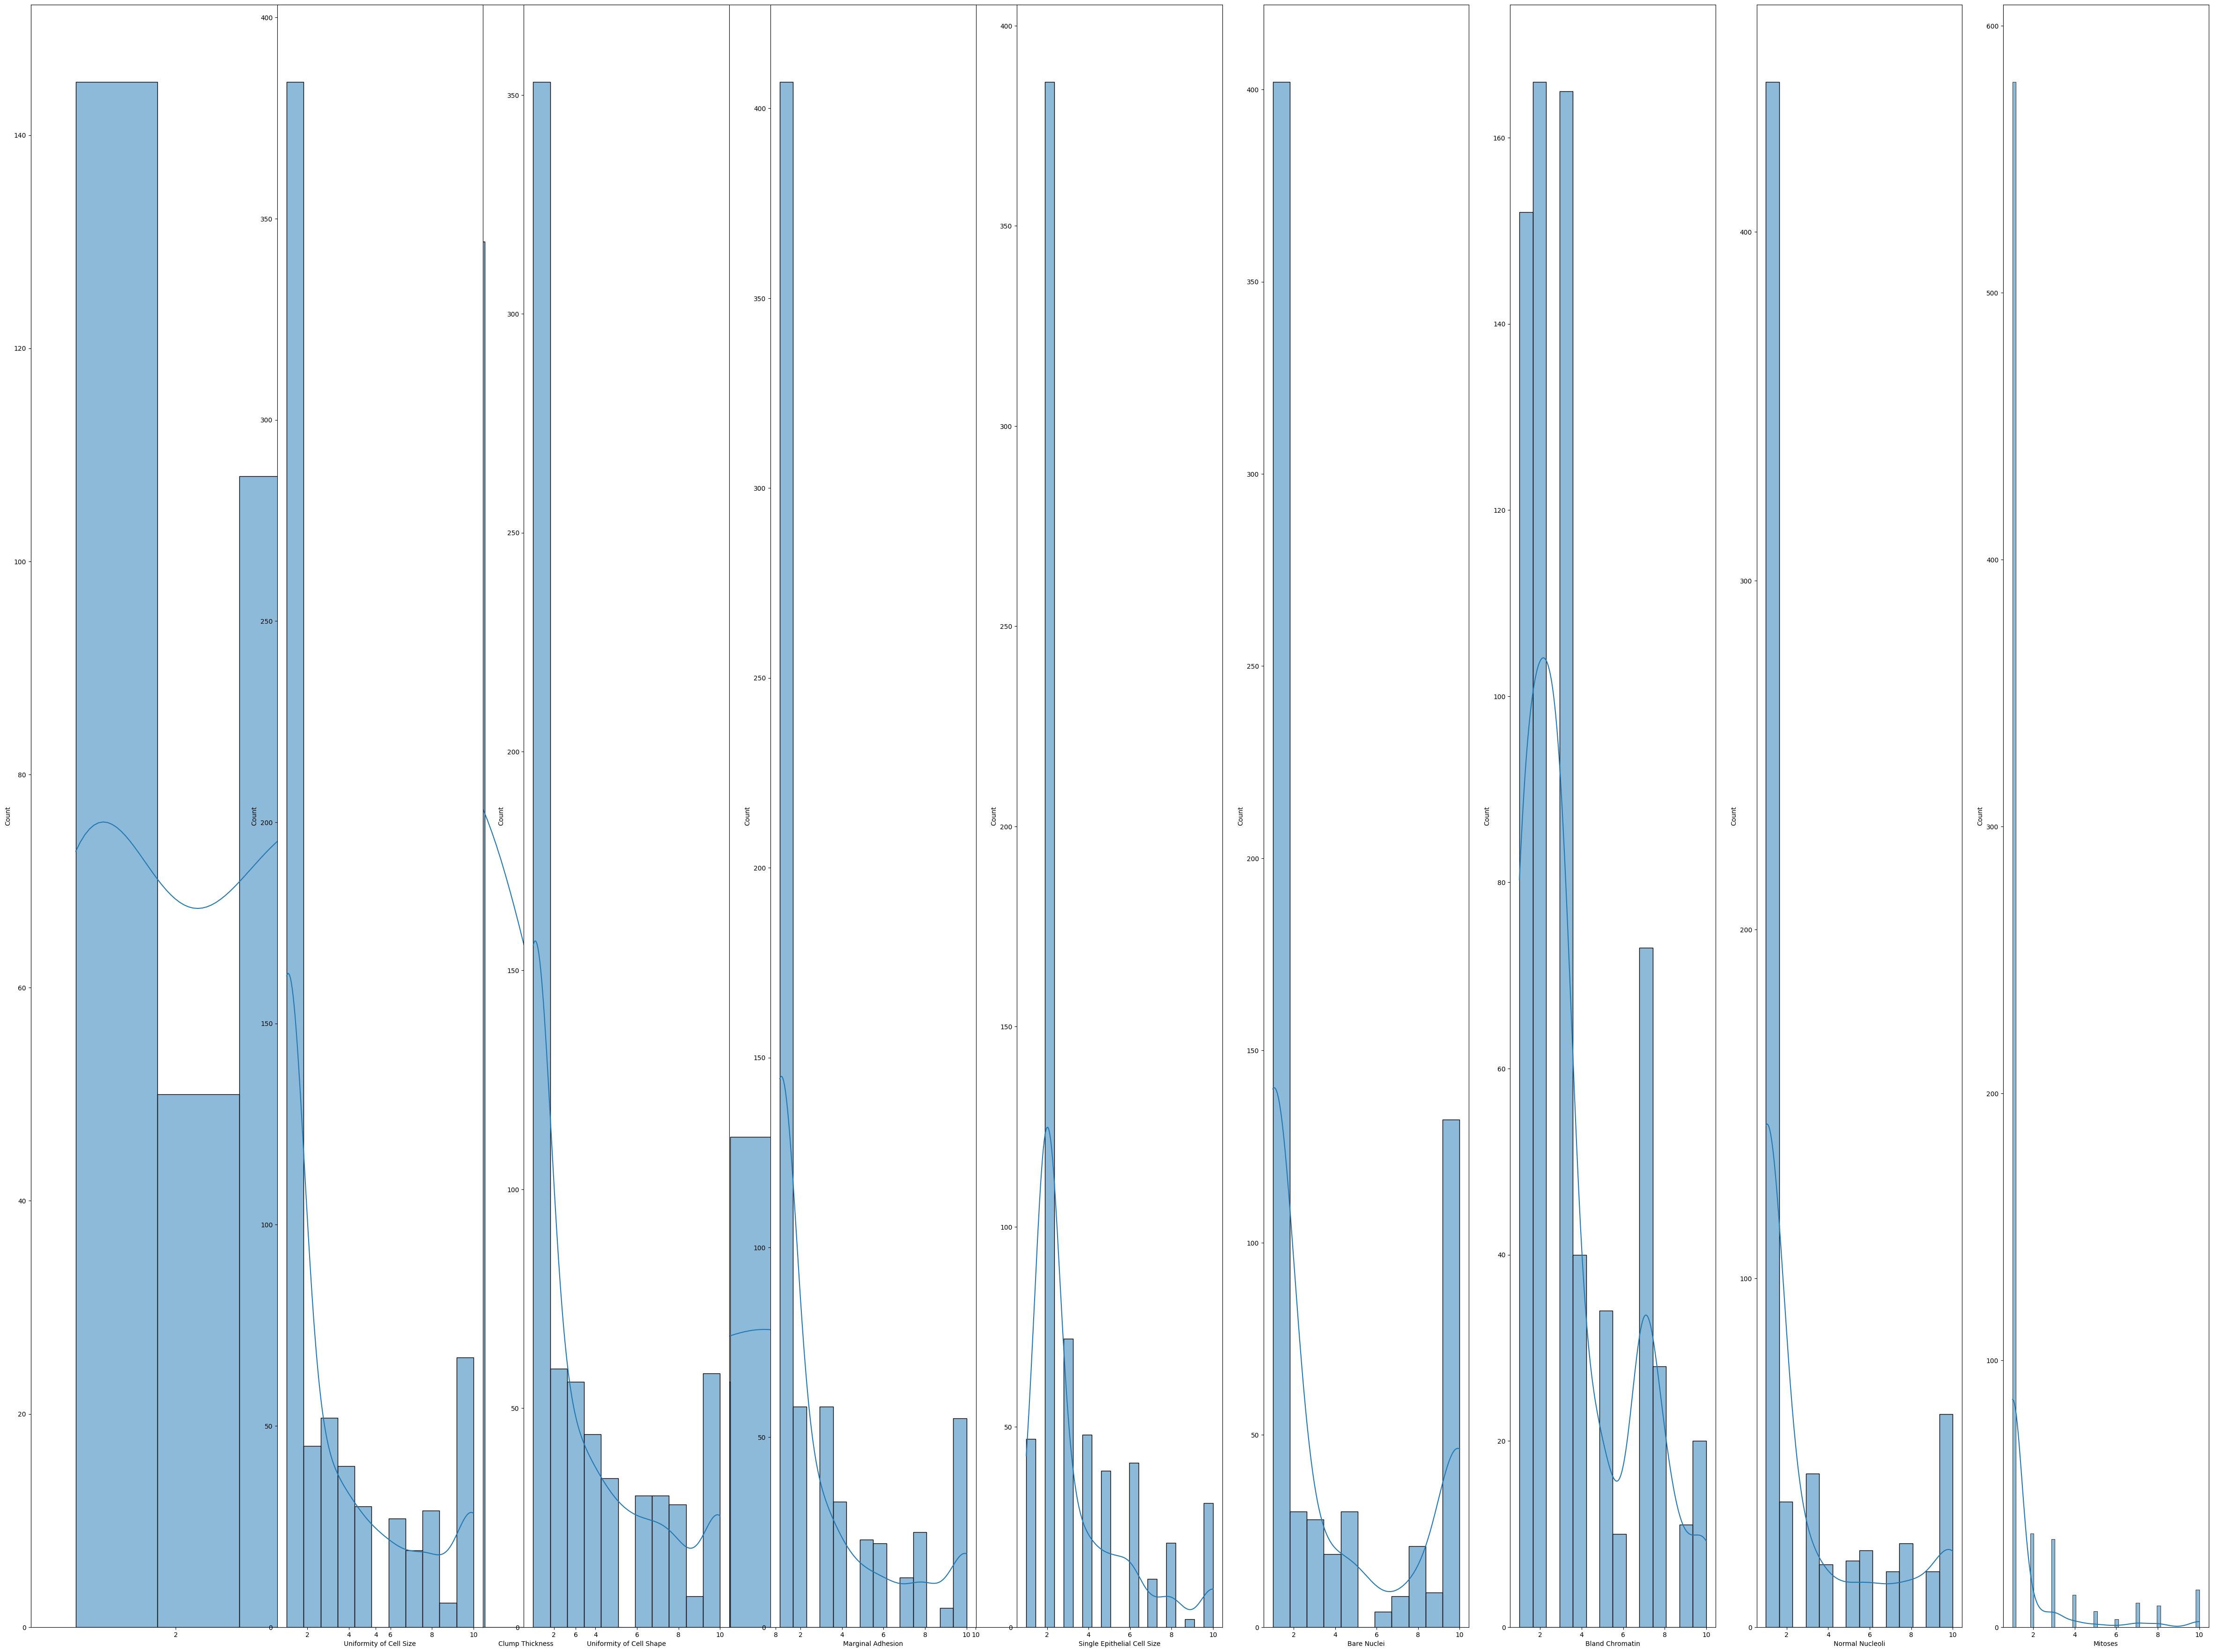

In [42]:
#Check the distribution of variables

fig = plt.figure(figsize = (60,5*9))

ax = fig.add_subplot(121)
sns.histplot(data = df, x = "Clump Thickness", kde = True, ax = ax)

ax = fig.add_subplot(192)
sns.histplot(data = df, x = "Uniformity of Cell Size", kde = True, ax = ax)

ax = fig.add_subplot(193)
sns.histplot(data = df, x = "Uniformity of Cell Shape", kde = True, ax = ax)

ax = fig.add_subplot(194)
sns.histplot(data = df, x = "Marginal Adhesion", kde = True, ax = ax)

ax = fig.add_subplot(195)
sns.histplot(data = df, x = "Single Epithelial Cell Size", kde = True, ax = ax)

ax = fig.add_subplot(196)
sns.histplot(data = df, x = "Bare Nuclei", kde = True, ax = ax)

ax = fig.add_subplot(197)
sns.histplot(data = df, x = "Bland Chromatin", kde = True, ax = ax)

ax = fig.add_subplot(198)
sns.histplot(data = df, x = "Normal Nucleoli", kde = True, ax = ax)

ax = fig.add_subplot(199)
sns.histplot(data = df, x = "Mitoses", kde = True, ax = ax)

### Estimating correlation coefficients

In [45]:
#the range of correlation is from -1 to 1 (-1: negative, 0: no correlation, 1: positive)
correlation = df.corr()
correlation["Class"].sort_values(ascending = False)

Class                          1.000000
Bare Nuclei                    0.822696
Uniformity of Cell Shape       0.818934
Uniformity of Cell Size        0.817904
Bland Chromatin                0.756616
Clump Thickness                0.716001
Normal Nucleoli                0.712244
Marginal Adhesion              0.696800
Single Epithelial Cell Size    0.682785
Mitoses                        0.423170
Name: Class, dtype: float64

[Text(0, 0.5, 'Clump Thickness'),
 Text(0, 1.5, 'Uniformity of Cell Size'),
 Text(0, 2.5, 'Uniformity of Cell Shape'),
 Text(0, 3.5, 'Marginal Adhesion'),
 Text(0, 4.5, 'Single Epithelial Cell Size'),
 Text(0, 5.5, 'Bare Nuclei'),
 Text(0, 6.5, 'Bland Chromatin'),
 Text(0, 7.5, 'Normal Nucleoli'),
 Text(0, 8.5, 'Mitoses'),
 Text(0, 9.5, 'Class')]

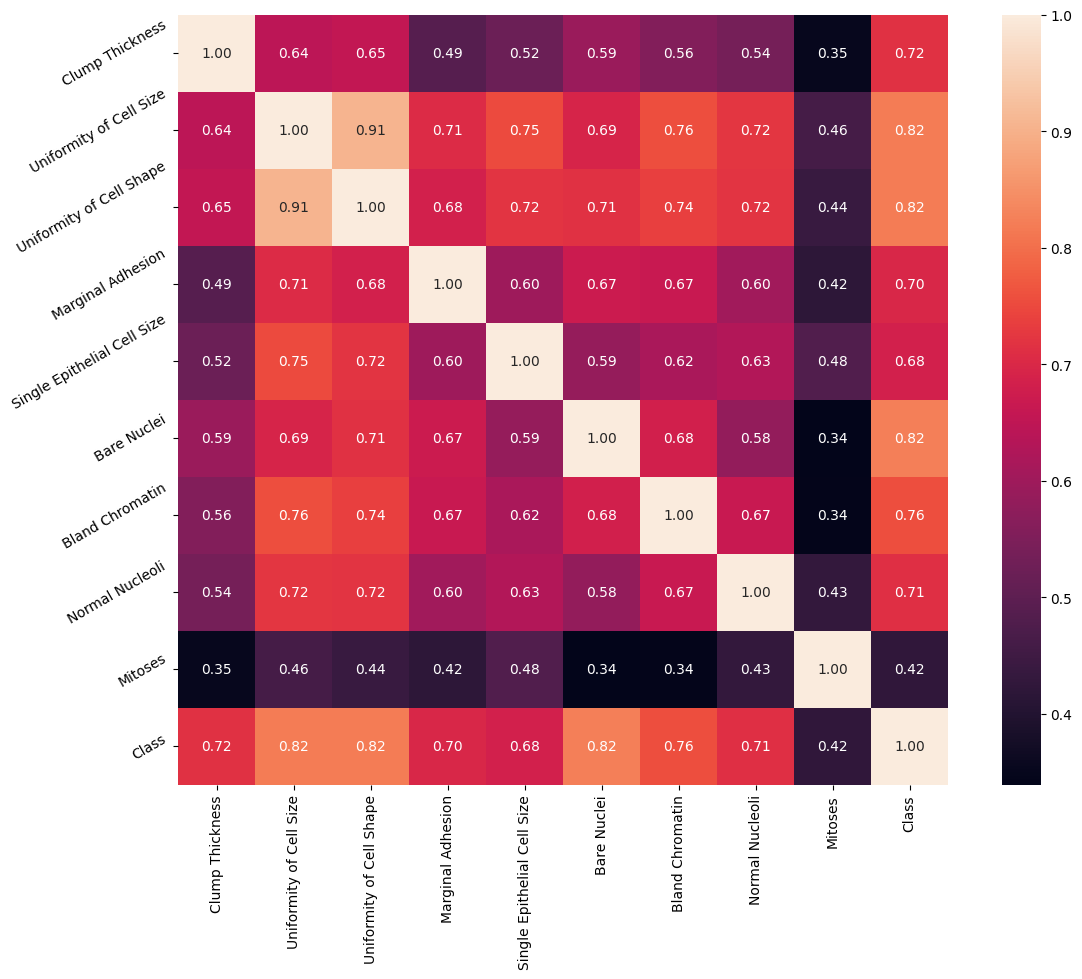

In [49]:
#describe the distribution of each element based on heatmap
plt.figure (figsize = (14,10))
ax = sns.heatmap(correlation, square = True, annot = True, fmt = ".2f", linecolor = 'white')
ax.set_xticklabels(ax.get_xticklabels(), rotation = 90)
ax.set_yticklabels(ax.get_yticklabels(), rotation = 30)

In [50]:
#Declare feature vector and target variable

X = df.drop(["Class"], axis = 1)
y = df["Class"]

In [51]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size = 0.3, random_state = 0)

In [55]:
#fix the missing values in variables
X_train.isnull().sum()
X_test.isnull().sum()

Clump Thickness                0
Uniformity of Cell Size        0
Uniformity of Cell Shape       0
Marginal Adhesion              0
Single Epithelial Cell Size    0
Bare Nuclei                    4
Bland Chromatin                0
Normal Nucleoli                0
Mitoses                        0
dtype: int64

### Processing the missing values

In general, we have two main methods to process missing values.

1. The first is using $\text{Mean/Median}$. This method keeps the data consistent and is safer for algorithms like Linear Regression or kNN. Since these models rely on distance calculations, using a stable value like the $\text{Mean}$ or $\text{Median}$ helps them find the correct formula faster and easier.

2. The second is $\text{Random Sample Imputation}$. This method helps us keep the original shape of the data distribution. It is perfect for Tree-based algorithms because it avoids creating a single repeated value ($\text{Mean/Median}$), which can confuse the tree when splitting nodes. Moreover, the randomness helps reduce overfitting in the tree model.

In [56]:
#Processing the missing values

for i in X_train.columns:
    col_median = X_train[i].median()
    X_train[i].fillna(col_median, inplace = True)
    col_median_test = X_test[i].median()
    X_test[i].fillna(col_median_test, inplace = True)

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_30460\824443051.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X_train[i].fillna(col_median, inplace = True)
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_30460\824443051.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example,

In [57]:
X_train.isnull().sum()

Clump Thickness                0
Uniformity of Cell Size        0
Uniformity of Cell Shape       0
Marginal Adhesion              0
Single Epithelial Cell Size    0
Bare Nuclei                    0
Bland Chromatin                0
Normal Nucleoli                0
Mitoses                        0
dtype: int64

In [58]:
X_test.isnull().sum()

Clump Thickness                0
Uniformity of Cell Size        0
Uniformity of Cell Shape       0
Marginal Adhesion              0
Single Epithelial Cell Size    0
Bare Nuclei                    0
Bland Chromatin                0
Normal Nucleoli                0
Mitoses                        0
dtype: int64

In [59]:
X_test.head()

,Clump Thickness,Uniformity of Cell Size,Uniformity of Cell Shape,Marginal Adhesion,Single Epithelial Cell Size,Bare Nuclei,Bland Chromatin,Normal Nucleoli,Mitoses
476,4,1,2,1,2,1.0,1,1,1
531,4,2,2,1,2,1.0,2,1,1
40,6,6,6,9,6,1.0,7,8,1
432,5,1,1,1,2,1.0,2,2,1
14,8,7,5,10,7,9.0,5,5,4


In [60]:
X_train.head()

,Clump Thickness,Uniformity of Cell Size,Uniformity of Cell Shape,Marginal Adhesion,Single Epithelial Cell Size,Bare Nuclei,Bland Chromatin,Normal Nucleoli,Mitoses
285,8,10,10,10,8,10.0,10,7,3
71,6,10,2,8,10,2.0,7,8,10
519,4,7,8,3,4,10.0,9,1,1
407,1,1,1,1,2,1.0,2,1,1
603,5,4,6,8,4,1.0,8,10,1
